In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv('/content/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [12]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


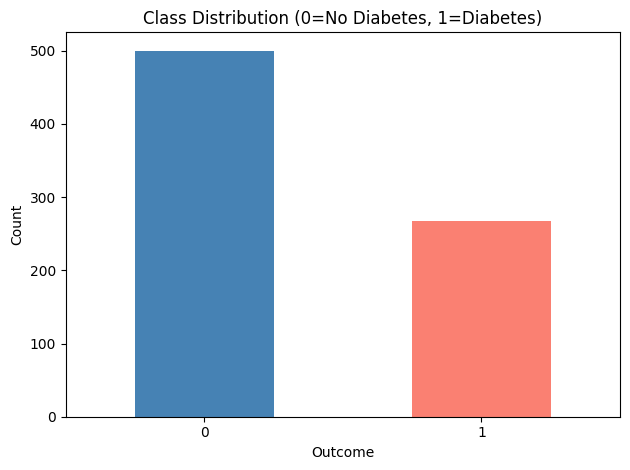

In [13]:
df['Outcome'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title('Class Distribution (0=No Diabetes, 1=Diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Class Distribution

This bar chart visualizes the distribution of the `Outcome` variable, which represents whether a patient has diabetes (1) or not (0).

*   **Interpretation**: We can see the count of patients in each class. This helps in understanding the class balance of the target variable. In this dataset, there are more patients without diabetes (0) than with diabetes (1), indicating a class imbalance. This imbalance might need to be addressed during model training to prevent the model from being biased towards the majority class.

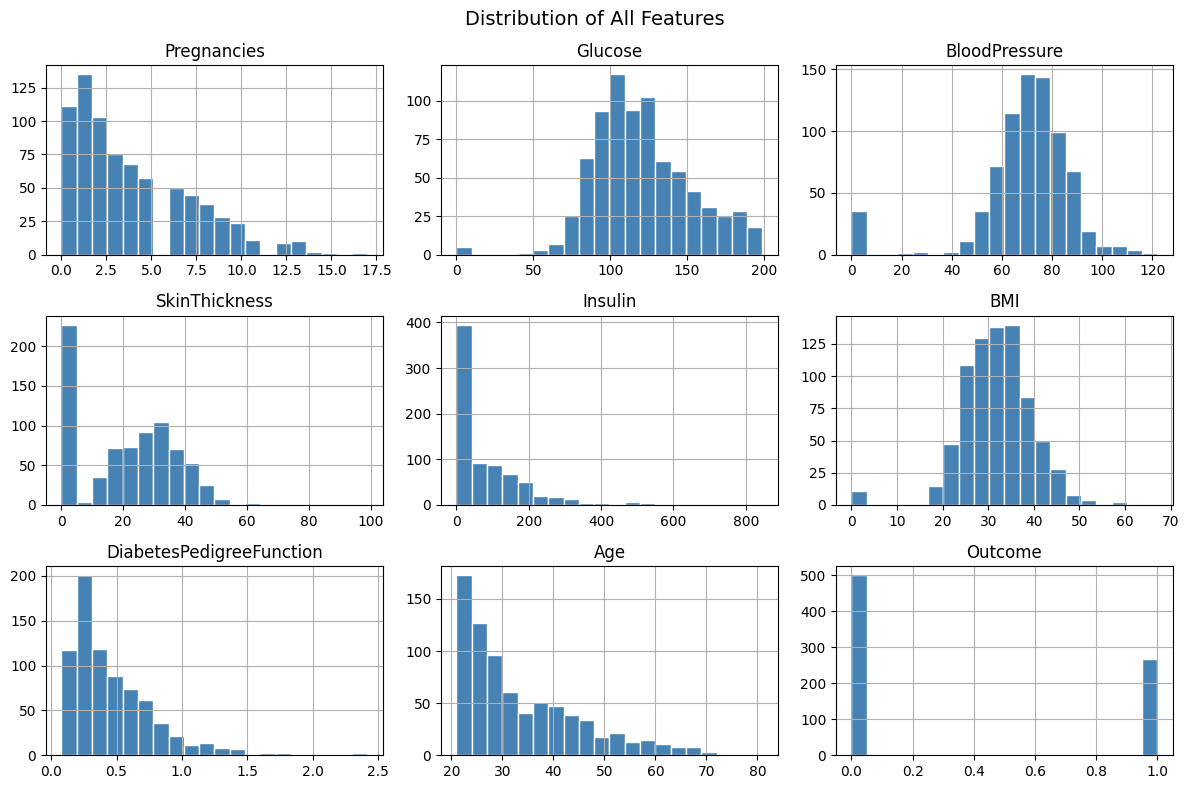

In [14]:
df.hist(figsize=(12, 8), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Distribution of All Features', fontsize=14)
plt.tight_layout()
plt.show()

# --- Explanation for ModuleNotFoundError in cell RtDAWwj-WqFM ---
# The error "ModuleNotFoundError: No module named 'sklearn.model'" indicates a typo in the import statement.
# The correct module for 'train_test_split' is 'sklearn.model_selection'.
# You should correct the import statement in cell RtDAWwj-WqFM from:
# 'from sklearn.model.selection import train_test_split'
# to the correct version below:
from sklearn.model_selection import train_test_split

### Distribution of All Features

These histograms display the individual distribution of each feature in the dataset.

*   **Interpretation**: Histograms help us understand the spread, central tendency, and shape of each feature's data. We can identify if features are normally distributed, skewed, or have multiple modes. They also help in detecting outliers or potential issues like values that are biologically impossible (e.g., BloodPressure = 0, which we addressed earlier by replacing with the median).

## Data Preprocessing

In [15]:
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
print("\nZero counts (these are actually missing values):")
print((df[zero_cols] == 0).sum())


Zero counts (these are actually missing values):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [16]:
zero_not_allowed = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_not_allowed:
  df[col] = df[col].replace(0, np.nan)
  df[col] = df[col].fillna(df[col].median())


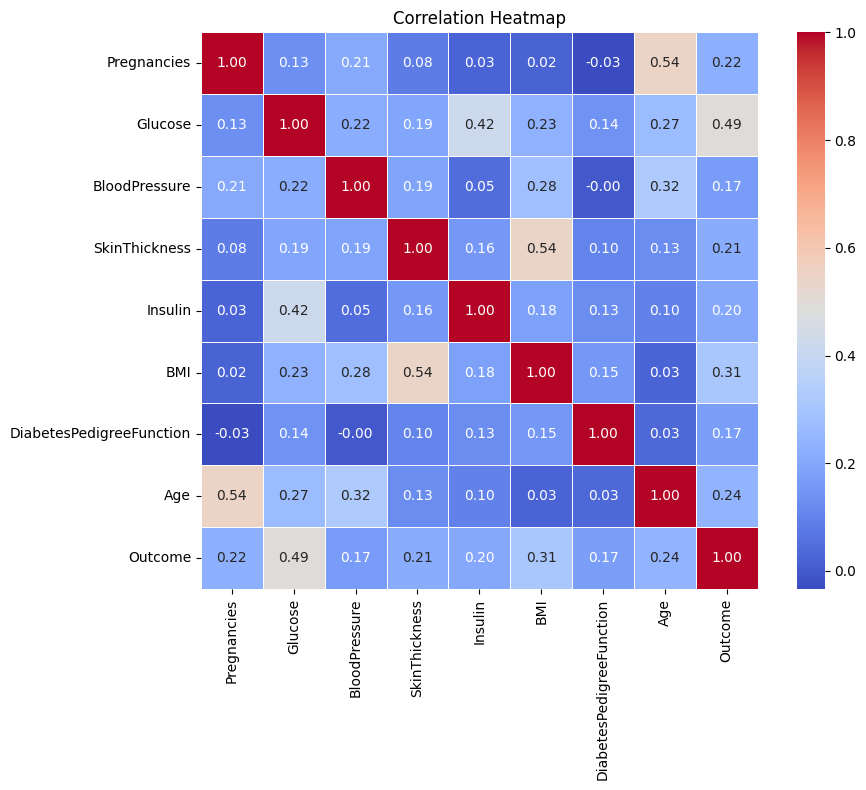

In [17]:

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Correlation Heatmap

This heatmap visualizes the Pearson correlation coefficients between all pairs of numerical features in the dataset.

*   **Interpretation**:
    *   Values close to **+1** (redder shades) indicate a strong positive linear correlation (as one variable increases, the other tends to increase).
    *   Values close to **-1** (bluer shades) indicate a strong negative linear correlation (as one variable increases, the other tends to decrease).
    *   Values close to **0** (cooler shades around the middle of the spectrum) indicate a weak or no linear correlation.
    *   This plot helps in identifying highly correlated features, which might be redundant, and understanding which features have a stronger relationship with the `Outcome` variable.

## Feature Engineering

In [18]:
# Doctors classify BMI into categories — more meaningful than raw number
def bmi_category(bmi):
    if bmi < 18.5:
        return 0  # Underweight
    elif bmi < 25:
        return 1  # Normal
    elif bmi < 30:
        return 2  # Overweight
    else:
        return 3  # Obese

df['BMI_Category'] = df['BMI'].apply(bmi_category)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,3
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,2
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,2
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,3


In [19]:
# Group ages into life stages
def age_group(age):
    if age < 30:
        return 0  # Young
    elif age < 45:
        return 1  # Middle aged
    else:
        return 2  # Senior

df['Age_Group'] = df['Age'].apply(age_group)

In [20]:

def glucose_category(g):
    if g < 100:
        return 0  # Normal
    elif g < 126:
        return 1  # Pre-diabetic
    else:
        return 2  # Diabetic range

df['Glucose_Category'] = df['Glucose'].apply(glucose_category)

In [21]:

df['Insulin_Glucose_Ratio'] = df['Insulin'] / (df['Glucose'] + 1)

In [22]:
df['BMI_Age'] = df['BMI'] * df['Age']

In [23]:

df['High_Pregnancy_Risk'] = (df['Pregnancies'] > 5).astype(int)

In [24]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Category,Insulin_Glucose_Ratio,BMI_Age,High_Pregnancy_Risk
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,3,2,2,0.838926,1680.0,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,2,1,0,1.453488,824.6,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,1,1,2,0.679348,745.6,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,2,0,0,1.044444,590.1,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,3,1,2,1.217391,1422.3,0


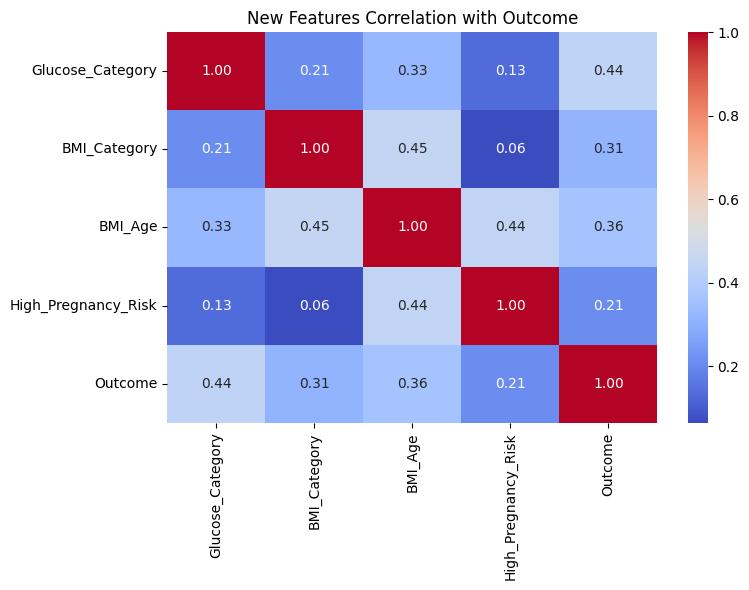

In [25]:
new_features = ['Glucose_Category', 'BMI_Category', 'BMI_Age', 'High_Pregnancy_Risk', 'Outcome']

plt.figure(figsize=(8,6))
sns.heatmap(df[new_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('New Features Correlation with Outcome')
plt.tight_layout()
plt.show()

### New Features Correlation with Outcome

This heatmap specifically displays the correlation coefficients between the newly engineered features and the `Outcome` variable, along with their inter-correlations.

*   **Interpretation**: Similar to the overall correlation heatmap, this plot helps assess the direct linear relationship of the engineered features with the target variable (`Outcome`). It's crucial for understanding if the new features are providing valuable predictive signal and how they relate to each other. Stronger correlations with `Outcome` suggest more predictive power from that feature.

## Splitting Training Data

In [26]:
df = df.drop(columns=['Insulin_Glucose_Ratio', 'Age_Group'])

In [27]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
print("X shape:", X.shape)  # should be (768, 12) approx
print("y shape:", y.shape)  # should be (768,)
print("\nFeatures used:\n", X.columns.tolist())


X shape: (768, 12)
y shape: (768,)

Features used:
 ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_Category', 'Glucose_Category', 'BMI_Age', 'High_Pregnancy_Risk']


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42,    # fixes randomness so results are reproducible
    stratify=y          # keeps 65/35 ratio in both train and test
)

In [29]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True).round(2))
print("Test class balance:\n",  y_test.value_counts(normalize=True).round(2))

X_train shape: (614, 12)
y_train shape: (614,)
X_test shape: (154, 12)
y_test shape: (154,)

Train class balance:
 Outcome
0    0.65
1    0.35
Name: proportion, dtype: float64
Test class balance:
 Outcome
0    0.65
1    0.35
Name: proportion, dtype: float64


In [30]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)


In [31]:
from sklearn.linear_model import LogisticRegression

model = model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Evaluation

In [32]:
y_pred = model.predict(X_test)           # class prediction (0 or 1)
y_prob = model.predict_proba(X_test)[:,1] # probability of diabetes

print("First 10 predictions:", y_pred[:10])
print("First 10 actual:     ", y_test.values[:10])


First 10 predictions: [1 0 0 0 0 0 1 1 0 1]
First 10 actual:      [0 0 0 1 0 0 1 1 0 0]


In [33]:
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc:.2%}")

# AUC-ROC
auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC  : {auc:.2f}")

# Full report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Diabetes','Diabetes']))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 74.68%
AUC-ROC  : 0.82

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.86      0.73      0.79       100
    Diabetes       0.61      0.78      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.77      0.75      0.75       154

Confusion Matrix:
[[73 27]
 [12 42]]


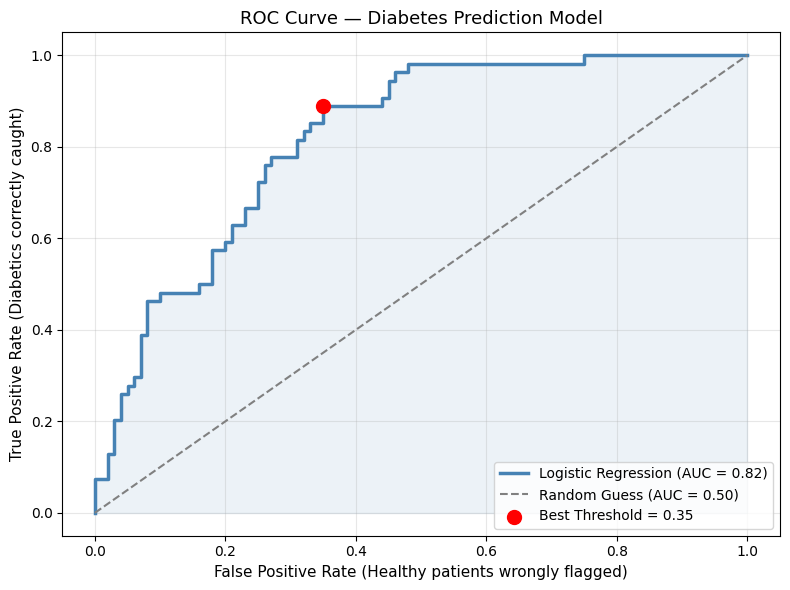


AUC-ROC Score: 0.82
Best Threshold: 0.35
At this point → TPR: 0.89, FPR: 0.35


In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities
y_prob = model.predict_proba(X_test)[:,1]

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8, 6))

# Main ROC curve
plt.plot(fpr, tpr, color='steelblue', lw=2.5,
         label=f'Logistic Regression (AUC = {auc:.2f})')

# Random guess line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         lw=1.5, label='Random Guess (AUC = 0.50)')

# Best threshold point
optimal_idx = (tpr - fpr).argmax()  # best point on curve
plt.scatter(fpr[optimal_idx], tpr[optimal_idx],
            color='red', s=100, zorder=5,
            label=f'Best Threshold = {thresholds[optimal_idx]:.2f}')

# Shading under curve
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')

# Labels
plt.xlabel('False Positive Rate (Healthy patients wrongly flagged)', fontsize=11)
plt.ylabel('True Positive Rate (Diabetics correctly caught)', fontsize=11)
plt.title('ROC Curve — Diabetes Prediction Model', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')  # saves for GitHub
plt.show()

print(f"\nAUC-ROC Score: {auc:.2f}")
print(f"Best Threshold: {thresholds[optimal_idx]:.2f}")
print(f"At this point → TPR: {tpr[optimal_idx]:.2f}, FPR: {fpr[optimal_idx]:.2f}")

### Understanding the ROC Curve

The **Receiver Operating Characteristic (ROC) curve** is a performance measurement for classification problems at various threshold settings. It illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied.

*   **True Positive Rate (TPR)**: Also known as sensitivity, recall, or probability of detection. It's the proportion of actual positives that are correctly identified as such.
*   **False Positive Rate (FPR)**: Also known as probability of false alarm. It's the proportion of actual negatives that are incorrectly identified as positives.
*   **Area Under the Curve (AUC)**: Represents the degree or measure of separability. It tells how much the model is capable of distinguishing between classes. The higher the AUC, the better the model is at predicting 0s as 0s and 1s as 1s.
*   **Best Threshold**: This point on the curve maximizes the difference between TPR and FPR, indicating an optimal balance between correctly identifying positives and minimizing false alarms.

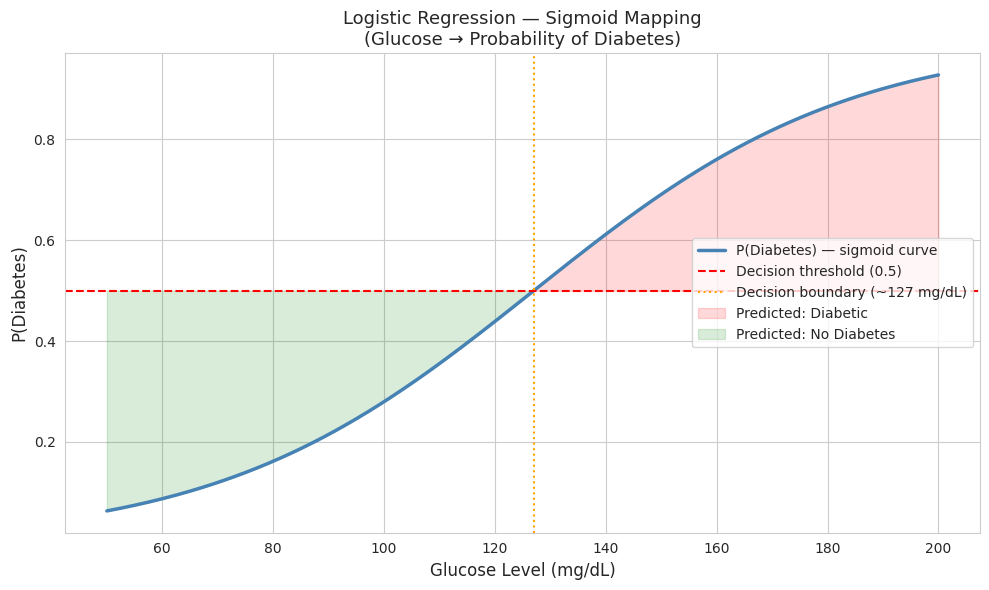

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Sigmoid function ───────────────────────────────────────────────────────
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ── 2. Generate glucose range ─────────────────────────────────────────────────
glucose = np.linspace(50, 200, 300)
z = 0.035 * (glucose - 127)          # linear combination (simplified)
probability = sigmoid(z)

# ── 3. Plot sigmoid curve ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Main sigmoid curve
plt.plot(glucose, probability, color='steelblue', lw=2.5,
         label='P(Diabetes) — sigmoid curve')

# Decision threshold line
plt.axhline(y=0.5, color='red', linestyle='--', lw=1.5,
            label='Decision threshold (0.5)')

# Threshold glucose point
plt.axvline(x=127, color='orange', linestyle=':', lw=1.5,
            label='Decision boundary (~127 mg/dL)')

# Shade regions
plt.fill_between(glucose, probability, 0.5,
                 where=(probability >= 0.5),
                 alpha=0.15, color='red', label='Predicted: Diabetic')

plt.fill_between(glucose, probability, 0.5,
                 where=(probability < 0.5),
                 alpha=0.15, color='green', label='Predicted: No Diabetes')

# Labels
plt.xlabel('Glucose Level (mg/dL)', fontsize=12)
plt.ylabel('P(Diabetes)', fontsize=12)
plt.title('Logistic Regression — Sigmoid Mapping\n(Glucose → Probability of Diabetes)',
          fontsize=13)
plt.legend(loc='center right', fontsize=10)
plt.tight_layout()
plt.savefig('sigmoid_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualizing the Sigmoid Function in Logistic Regression

This plot demonstrates how the **sigmoid function** transforms a linear combination of features (here, simplified to just glucose level) into a probability, ranging from 0 to 1.

*   **Sigmoid Curve**: This 'S'-shaped curve is the core of logistic regression. It maps any real-valued number into a probability. Values close to 0 on the x-axis (or very negative 'z' values) map to probabilities near 0, and values close to 1 on the x-axis (or very positive 'z' values) map to probabilities near 1.
*   **Decision Threshold (0.5)**: In binary classification, a probability of 0.5 is typically used as the cutoff. If `P(Diabetes)` is greater than 0.5, the model predicts diabetes (shaded red); otherwise, it predicts no diabetes (shaded green).
*   **Decision Boundary**: This is the point where the probability crosses the 0.5 threshold. In this simplified example, it corresponds to a glucose level of approximately 127 mg/dL. This is where the model switches its prediction from 'no diabetes' to 'diabetes'.

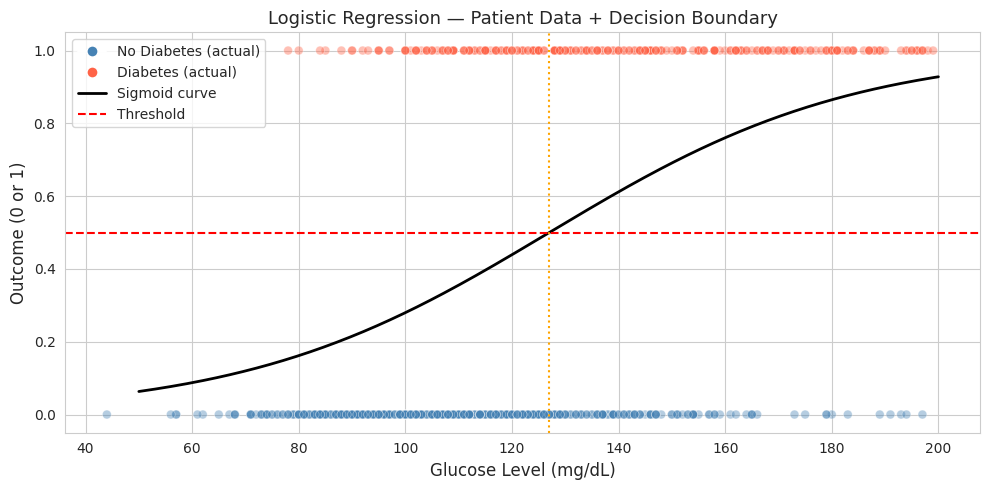

In [36]:

plt.figure(figsize=(10, 5))

# Plot actual patients from your dataset
sns.scatterplot(data=df, x='Glucose', y='Outcome',
                hue='Outcome', palette={0:'steelblue', 1:'tomato'},
                alpha=0.4, s=40,
                hue_order=[0, 1],
                legend=False)

# Overlay sigmoid curve
plt.plot(glucose, probability, color='black', lw=2, label='Sigmoid curve')
plt.axhline(y=0.5, color='red', linestyle='--', lw=1.5, label='Threshold (0.5)')
plt.axvline(x=127, color='orange', linestyle=':', lw=1.5, label='Decision boundary')

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=8, label='No Diabetes (actual)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
           markersize=8, label='Diabetes (actual)'),
    Line2D([0],[0], color='black', lw=2, label='Sigmoid curve'),
    Line2D([0],[0], color='red', lw=1.5, linestyle='--', label='Threshold'),
]
plt.legend(handles=legend_elements, fontsize=10)

plt.xlabel('Glucose Level (mg/dL)', fontsize=12)
plt.ylabel('Outcome (0 or 1)', fontsize=12)
plt.title('Logistic Regression — Patient Data + Decision Boundary', fontsize=13)
plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

### Patient Data Overlayed with Logistic Regression Decision Boundary

This visualization combines the actual patient data with the derived sigmoid curve and decision boundary, illustrating how the logistic regression model classifies individuals based on their glucose levels.

*   **Actual Patient Outcomes**: Individual scatter points represent patients, with their glucose level on the x-axis and their actual diabetes outcome (0 for no diabetes, 1 for diabetes) on the y-axis. The colors (steelblue for no diabetes, tomato for diabetes) distinguish them.
*   **Sigmoid Curve**: The black line shows the model's predicted probability of diabetes across a range of glucose levels.
*   **Decision Boundary**: The vertical orange dashed line at approximately 127 mg/dL for glucose and the horizontal red dashed line at a probability of 0.5 define the model's classification rule. Patients to the left of the orange line (or below the red line on the sigmoid) are predicted as 'no diabetes', while those to the right (or above the red line) are predicted as 'diabetes'.

This plot helps to visually assess how well the model's decision boundary aligns with the distribution of actual diabetic and non-diabetic patients.

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ── All models in one dictionary ──────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'        : GaussianNB(),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'SVM'                : SVC(random_state=42, class_weight='balanced', probability=True)
}

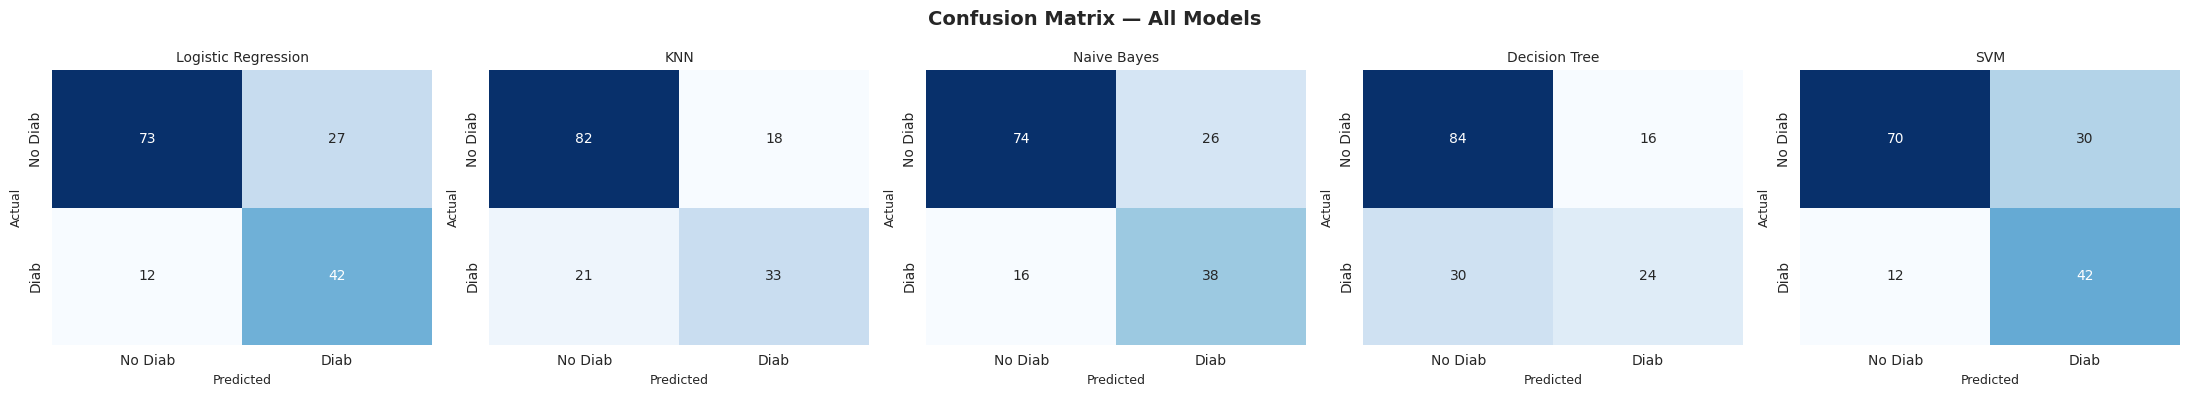

In [39]:
# ── Loop through every model ───────────────────────────────────────────────────
results = []  # store summary here

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Confusion Matrix — All Models', fontsize=14, fontweight='bold')

for idx, (name, model) in enumerate(models.items()):

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    rep  = classification_report(y_test, y_pred, output_dict=True)
    prec = rep['1']['precision']
    rec  = rep['1']['recall']
    f1   = rep['1']['f1-score']

    # Store results
    results.append({
        'Model'    : name,
        'Accuracy' : round(acc * 100, 2),
        'AUC-ROC'  : round(auc, 2),
        'Precision': round(prec, 2),
        'Recall'   : round(rec, 2),
        'F1 Score' : round(f1, 2)
    })

    # Confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[idx], cbar=False,
                xticklabels=['No Diab', 'Diab'],
                yticklabels=['No Diab', 'Diab'])
    axes[idx].set_title(name, fontsize=10)
    axes[idx].set_xlabel('Predicted', fontsize=9)
    axes[idx].set_ylabel('Actual', fontsize=9)

plt.tight_layout()

plt.show()

In [40]:
# ── Performance Summary Table ──────────────────────────────────────────────────
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print("=" * 65)
print("          MODEL PERFORMANCE SUMMARY")
print("=" * 65)
print(df_results.to_string(index=False))
print("=" * 65)
print(f"\n🏆 Best Model (AUC-ROC): {df_results.iloc[0]['Model']}")
print(f"   AUC-ROC  : {df_results.iloc[0]['AUC-ROC']}")
print(f"   Accuracy : {df_results.iloc[0]['Accuracy']}%")
print(f"   Recall   : {df_results.iloc[0]['Recall']}")

          MODEL PERFORMANCE SUMMARY
              Model  Accuracy  AUC-ROC  Precision  Recall  F1 Score
Logistic Regression     74.68     0.82       0.61    0.78      0.68
                SVM     72.73     0.81       0.58    0.78      0.67
                KNN     74.68     0.80       0.65    0.61      0.63
        Naive Bayes     72.73     0.80       0.59    0.70      0.64
      Decision Tree     70.13     0.64       0.60    0.44      0.51

🏆 Best Model (AUC-ROC): Logistic Regression
   AUC-ROC  : 0.82
   Accuracy : 74.68%
   Recall   : 0.78


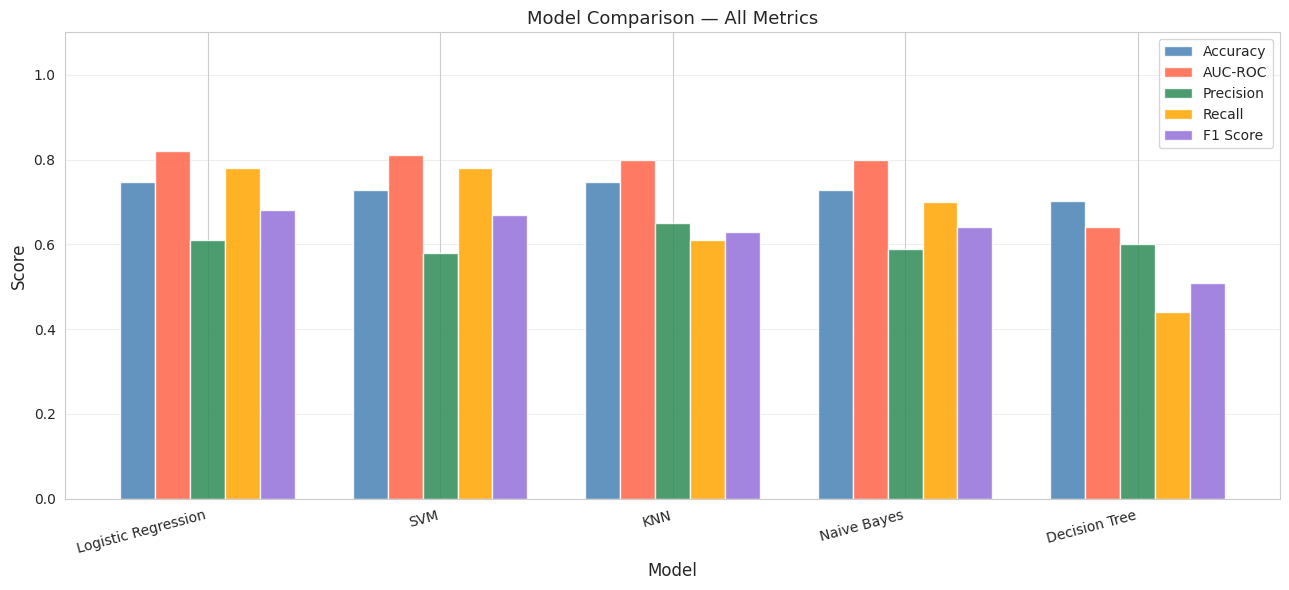

In [42]:
# ── Bar Chart — Visual Comparison ─────────────────────────────────────────────
metrics = ['Accuracy', 'AUC-ROC', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(df_results['Model']))
width = 0.15
colors = ['steelblue', 'tomato', 'seagreen', 'orange', 'mediumpurple']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = df_results[metric].values
    # normalize accuracy to 0-1 scale for fair comparison
    vals_plot = vals / 100 if metric == 'Accuracy' else vals
    bars = ax.bar(x + i * width, vals_plot, width, label=metric, color=color, alpha=0.85)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=13)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(df_results['Model'], rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
# plt.savefig('images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()